# Data Exploration

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import os
import random
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import torch.nn.functional as F
import torch
from torchvision import models

In [2]:
DATA_PATH = '/kaggle/input/polyvore-outfit-dataset/polyvore_outfits'
# Load item metadata
metadata_path = os.path.join(DATA_PATH, 'polyvore_item_metadata.json')

with open(metadata_path, 'r') as f:
    item_metadata = json.load(f)

print(f"{len(item_metadata)} items")



251008 items


In [3]:
# Show sample item
sample_id = list(item_metadata.keys())[0]
sample_item = item_metadata[sample_id]
sample_item


{'url_name': 'neck print chiffon plus size',
 'description': '',
 'title': '',
 'related': '',
 'category_id': '15',
 'semantic_category': 'tops',
 'categories': ''}

In [4]:
# Load categories CSV
categories_df = pd.read_csv(os.path.join(DATA_PATH, 'categories.csv'))

print(f"Categories shape: {categories_df.shape}")
print(categories_df.head(10))

# category distribution
print(categories_df['main_category'].value_counts())

Categories shape: (194, 3)
   category_id    sub_category main_category
0            3           dress      all-body
1            4           dress      all-body
2            5           dress      all-body
3            6            gown      all-body
4            7           skirt       bottoms
5            8           skirt       bottoms
6            9           skirt       bottoms
7           10      long skirt       bottoms
8           11         sweater          tops
9           11  sleeveless top          tops
main_category
tops            35
shoes           32
bottoms         31
accessories     22
bags            18
outerwear       13
all-body        11
jewellery        9
hats             6
jewellery        4
accessories      4
scarves          2
sunglasses       2
Name: count, dtype: int64


In [5]:
# Load compatibility training data

outfits = []
with open('/kaggle/input/polyvore-outfit-dataset/polyvore_outfits/disjoint/compatibility_train.txt', 'r') as f:
    for line in f:
        items = line.strip().split()
        outfits.append(items)

print(f" {len(outfits)} training outfits")

# Check outfit sizes so we can see what we are dealing with
outfit_sizes = [len(outfit) for outfit in outfits]
print(f"Outfit size range: {min(outfit_sizes)} - {max(outfit_sizes)}")

 33990 training outfits
Outfit size range: 3 - 17


Top 10 item categories:
  shoes: 44850
  jewellery: 41414
  bags: 40717
  tops: 32998
  bottoms: 27670
  all-body: 18478
  outerwear: 17065
  sunglasses: 9874
  accessories: 6973
  hats: 6071


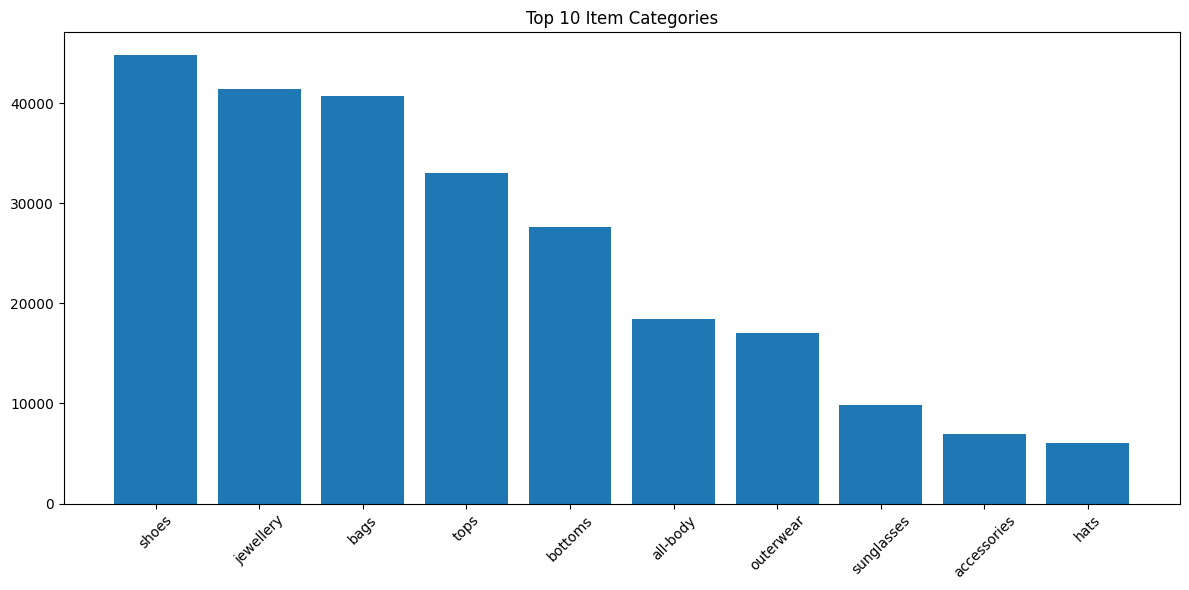

In [6]:
# Item category distribution
categories = [item.get('semantic_category', 'Unknown') for item in item_metadata.values()]
category_counts = Counter(categories)

print("Top 10 item categories:")
for category, count in category_counts.most_common(10):
    print(f"  {category}: {count}")

# Plot category distribution
plt.figure(figsize=(12, 6))
top_cats = dict(category_counts.most_common(10))
plt.bar(range(len(top_cats)), list(top_cats.values()))
plt.xticks(range(len(top_cats)), list(top_cats.keys()), rotation=45)
plt.title('Top 10 Item Categories')
plt.tight_layout()
plt.show()

In [7]:
# Check what the actual item IDs look like in metadata
print("Sample item IDs from metadata:")
sample_ids = list(item_metadata.keys())[:10]
for i, item_id in enumerate(sample_ids):
    print(f"  {i+1}. '{item_id}'")

print(f"Sample outfit item IDs: {outfits[0][:5]}")
print(f"Sample metadata item IDs: {sample_ids[:5]}")

Sample item IDs from metadata:
  1. '211990161'
  2. '183179503'
  3. '152771755'
  4. '190445143'
  5. '211444470'
  6. '192704091'
  7. '117334561'
  8. '127403908'
  9. '149817672'
  10. '210309753'
Sample outfit item IDs: ['1', '199244701_1', '199244701_2', '199244701_3', '199244701_4']
Sample metadata item IDs: ['211990161', '183179503', '152771755', '190445143', '211444470']


# Data Preparation

In [8]:
# Load the JSON training file
with open('/kaggle/input/polyvore-outfit-dataset/polyvore_outfits/disjoint/train.json', 'r') as f:
    train_outfits_json = json.load(f)

with open('/kaggle/input/polyvore-outfit-dataset/polyvore_outfits/polyvore_item_metadata.json', 'r') as f:
    item_metadata = json.load(f)

print(f"Loaded {len(train_outfits_json)} outfits from JSON")
print(f"Loaded {len(item_metadata)} items metadata")

# This shows the item id - Index structure for the pairs
print(f"Sample outfit structure: {train_outfits_json[0]}")

Loaded 16995 outfits from JSON
Loaded 251008 items metadata
Sample outfit structure: {'items': [{'item_id': '132621870', 'index': 1}, {'item_id': '153967122', 'index': 2}, {'item_id': '171169800', 'index': 3}, {'item_id': '162799044', 'index': 4}, {'item_id': '172538912', 'index': 5}, {'item_id': '172312529', 'index': 6}], 'set_id': '199244701'}


This is going to create positive pairs. The positive pairs will be the ones we are going to take from the outfits. This means that they are the ones we want the model to understand they are okay. 

In [9]:
# Create positive pairs - items that appear together in same outfit
positive_pairs = []

# This is going to be a set so we dont repeat the same outfits
all_valid_items = set()

# Creates the outfits 
for outfit_idx, outfit in enumerate(train_outfits_json):
    # This is just to test and show (just wanted to make sure it was processing )
    #if outfit_idx % 1000 == 0:
    #   print(f"Processing outfit {outfit_idx}/{len(train_outfits_json)}")
    
    # Get valid items from this outfit
    outfit_items = []
    for item in outfit['items']:
        item_id = item['item_id']
        if item_id in item_metadata:
            category = item_metadata[item_id].get('semantic_category', 'Unknown')
            if category != 'Unknown':
                outfit_items.append(item_id)
                all_valid_items.add(item_id)
    
    # Create all possible pairs within this outfit (positive pairs)
    for i in range(len(outfit_items)):
        for j in range(i + 1, len(outfit_items)):
            positive_pairs.append((outfit_items[i], outfit_items[j], 1))

print(f"Created {len(positive_pairs)} positive pairs")

# Track which items appear together for negative sampling
# This might not be necessary, yet I added it because I wanted to try it. 
item_cooccurrence = {}
for item in all_valid_items:
    item_cooccurrence[item] = set()

for item1, item2, _ in positive_pairs:
    item_cooccurrence[item1].add(item2)
    item_cooccurrence[item2].add(item1)

Created 192892 positive pairs


This is going to create negative pairs. I tried creating them the same way I created the positive pair, but it was taking a long time because there are more items not in the outfits and creating the pairs like that would take a long time. I used sampling to create the negative pairs, therefore it is random and not ideal, but I did it like this for the sake of time. You could try other ways to create the negative pairs

The Logic:

Positive pairs: Items that appeared together in the same outfit (compatible)
Negative pairs: Items that NEVER appeared together in any outfit (incompatible)

This assumes that if two fashion items never appeared together across thousands of outfits, they're likely incompatible style-wise. It's a reasonable heuristic for fashion compatibility!

In [10]:


# Create negative pairs - sample instead of exhaustive
negative_pairs = []
all_valid_items_list = list(all_valid_items)
# 2x more negatives than positives. I wanted to have more negative pairs. I tried a balanced dataset and
# it did not work well, besides SNNs are good with unbalaced data, this could be modified
target_negative_pairs = len(positive_pairs) * 2  

# If you can't find enough incompatible pairs, it stops trying
attempts = 0
max_attempts = target_negative_pairs * 10 # prevents infinet loops 

while len(negative_pairs) < target_negative_pairs and attempts < max_attempts:
    item1, item2 = random.sample(all_valid_items_list, 2)
    if item2 not in item_cooccurrence[item1]:
        negative_pairs.append((item1, item2, 0))
    attempts += 1

print(f"Created {len(negative_pairs)} negative pairs")

Created 385784 negative pairs


Combines the pairs and creates a summary table

In [11]:
# Combine all pairs
all_pairs = positive_pairs + negative_pairs
random.shuffle(all_pairs)

print(f"\nDataset Summary:")
print(f"Total pairs: {len(all_pairs)}")
print(f"Positive pairs: {len(positive_pairs)} ({len(positive_pairs)/len(all_pairs)*100:.1f}%)")
print(f"Negative pairs: {len(negative_pairs)} ({len(negative_pairs)/len(all_pairs)*100:.1f}%)")

# Show examples
print(f"\nSample positive pairs (items from same outfits):")
for i in range(min(5, len(positive_pairs))):
    item1, item2, label = positive_pairs[i]
    cat1 = item_metadata[item1].get('semantic_category', 'Unknown')
    cat2 = item_metadata[item2].get('semantic_category', 'Unknown')
    print(f"  {item1} ({cat1}) + {item2} ({cat2}) = Compatible")

print(f"\nSample negative pairs (items that never appeared together):")
for i in range(min(5, len(negative_pairs))):
    item1, item2, label = negative_pairs[i]
    cat1 = item_metadata[item1].get('semantic_category', 'Unknown')
    cat2 = item_metadata[item2].get('semantic_category', 'Unknown')
    print(f"  {item1} ({cat1}) + {item2} ({cat2}) = Incompatible")


Dataset Summary:
Total pairs: 578676
Positive pairs: 192892 (33.3%)
Negative pairs: 385784 (66.7%)

Sample positive pairs (items from same outfits):
  132621870 (bags) + 153967122 (shoes) = Compatible
  132621870 (bags) + 171169800 (jewellery) = Compatible
  132621870 (bags) + 162799044 (jewellery) = Compatible
  132621870 (bags) + 172538912 (jewellery) = Compatible
  132621870 (bags) + 172312529 (all-body) = Compatible

Sample negative pairs (items that never appeared together):
  207052364 (jewellery) + 136473930 (tops) = Incompatible
  205492676 (sunglasses) + 155407108 (outerwear) = Incompatible
  209462553 (jewellery) + 207099526 (all-body) = Incompatible
  193884178 (jewellery) + 96221965 (outerwear) = Incompatible
  173981571 (shoes) + 139945265 (tops) = Incompatible


# Data preparation for the model

In [12]:
# Split into train/validation
train_size = int(0.8 * len(all_pairs))
train_pairs = all_pairs[:train_size]
val_pairs = all_pairs[train_size:]

print(f"\nData split:")
print(f"Training pairs: {len(train_pairs)}")
print(f"Validation pairs: {len(val_pairs)}")


Data split:
Training pairs: 462940
Validation pairs: 115736


In [13]:
class FashionDataset(Dataset):

    def __init__(self, pairs, item_metadata, images_dir, transform=None):
        self.pairs = pairs
        self.item_metadata = item_metadata
        self.images_dir = images_dir 
        self.transform = transform

    # DEbuggind prints 
        #print(f"Dataset initialized with {len(pairs)} pairs")
        #print(f"Looking for images in: {images_dir}")
    
    def load_image(self, item_id):
        """Loads images from dataset"""
        image_path = os.path.join(self.images_dir, f"{item_id}.jpg")
        
        try:
            image = Image.open(image_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image
        except:
            raise FileNotFoundError(f"Image not found for item {item_id}")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        item1_id, item2_id, label = self.pairs[idx]
        
        # Loads images
        image1 = self.load_image(item1_id)
        image2 = self.load_image(item2_id)
        
        return {
            'image1': image1,
            'image2': image2,
            'label': torch.tensor(label, dtype=torch.float32),
            'item1_id': item1_id,
            'item2_id': item2_id
        }

In [14]:
# Added data augmentation 
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# If you are using this in another place, change the path for the dataset
IMAGES_DIR = "/kaggle/input/polyvore-outfit-dataset/polyvore_outfits/images"

train_dataset = FashionDataset(
    train_pairs, 
    item_metadata, 
    images_dir=IMAGES_DIR,
    transform=train_transform
)

val_dataset = FashionDataset(
    val_pairs, 
    item_metadata, 
    images_dir=IMAGES_DIR,
    transform=val_transform
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Created train loader with {len(train_loader)} batches")
print(f"Created val loader with {len(val_loader)} batches")

Created train loader with 14467 batches
Created val loader with 3617 batches


# Model Architechture

This model sses pretrained ResNet50. We remove the last classification layer so we get a feature extractor that converts images to 2048-dimensional feature vectors. Freezes the first 20 layers of ResNet50 because those are the layers that learn basic stuff and we want to fine tune it for what we are trying to do 

In [15]:
class SiameseNetwork(nn.Module):
    """
    This is the network
    """
    def __init__(self, embedding_dim=128, dropout=0.3,):
        super(SiameseNetwork, self).__init__()
        
        self.backbone = models.resnet50(pretrained=True)
        backbone_output_dim = 2048
        
        # Remove the final classification layer
        self.feature_extractor = nn.Sequential(*list(self.backbone.children())[:-1])
        
        # Freeze early layers
        for param in list(self.feature_extractor.parameters())[:20]:
            param.requires_grad = False
        
        # Embedding layers with batch norm
        self.embedding = nn.Sequential(
            nn.Flatten(),                    # Flatten 2048 features
            nn.Linear(2048, 512),           # Compress to 512
            nn.BatchNorm1d(512),            # Normalize
            nn.ReLU(inplace=True),          # Activation
            nn.Dropout(dropout),            # Prevent overfitting
            nn.Linear(512, 128),            # Final embedding size
            nn.BatchNorm1d(128)             # Normalize
        )
        
        # Compatibility classifier
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout/2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward_once(self, x):
        """Forward pass for one item"""
        features = self.feature_extractor(x)
        embedding = self.embedding(features)
        # L2 normalize the embedding
        embedding = F.normalize(embedding, p=2, dim=1)
        return embedding
    
    def forward(self, image1, image2):
        """Forward pass for a pair of items"""
        # Get embeddings for both items
        embedding1 = self.forward_once(image1)
        embedding2 = self.forward_once(image2)
        
        # Concatenate embeddings
        combined = torch.cat([embedding1, embedding2], dim=1)
        
        # Predict compatibility
        compatibility = self.classifier(combined)
        
        return compatibility, embedding1, embedding2

In [16]:
# Checks device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Iniciate the model istance
model = SiameseNetwork(embedding_dim=128)
model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]


Model parameters: 26,755,881
Trainable parameters: 26,617,897


We are using contrastive loss and Binary Cross Entropy loss. This could be changed but I found this to be easier. I did a post about this in https://medium.com/@christianmijangos.cm/siamese-neural-networks-dfb84a4a37b3

In [17]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
    
    def forward(self, embedding1, embedding2, label):
        euclidean_distance = F.pairwise_distance(embedding1, embedding2)
        loss = torch.mean(
            label * torch.pow(euclidean_distance, 2) +
            (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)
        )
        return loss

Different learning rates - Smart approach:

Lower LR for pretrained ResNet (fine-tuning)
Higher LR for new layers (learning from scratch)


Scheduler - Reduces LR when validation stops improving
Weight decay - Regularization to prevent overfitting

In [18]:
# Setup training with contrastive loss and BCE
contrastive_loss = ContrastiveLoss(margin=2.0)
bce_loss = nn.BCELoss()

# Different learning rates for different parts
backbone_params = []
other_params = []

for name, param in model.named_parameters():
    if 'backbone' in name or 'feature_extractor' in name:
        backbone_params.append(param)
    else:
        other_params.append(param)

optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},  # Lower LR for pretrained backbone
    {'params': other_params, 'lr': 1e-3}      # Higher LR for new layers
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


# Training the Model

In [19]:
# All of this could be changed 
num_epochs = 5 # 5 because why not? 
best_val_acc = 0.0
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training phase
    model.train() # enable the droputs and BN
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, batch in enumerate(train_loader):
        # Move data to GPU
        image1 = batch['image1'].to(device)
        image2 = batch['image2'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass - get predictions
        compatibility, embedding1, embedding2 = model(image1, image2)
        
        # Calculate two types of loss and combine them 
        # This could also be changed
        loss1 = contrastive_loss(embedding1, embedding2, labels)
        loss2 = bce_loss(compatibility.squeeze(), labels)
        loss = 0.1 * loss1 + loss2  # Reduce contrastive loss weight
        
        # Backward pass - calculate gradients
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate training accuracy
        predicted = (compatibility.squeeze() > 0.5).float()
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        if batch_idx % 200 == 0:
            print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}, '
                  f'Acc: {train_correct/train_total:.4f}')
    
    # Validation phase
    model.eval() # Disable dropout, batch norm eval mode
    val_correct = 0
    val_total = 0
    val_loss = 0.0
    
    with torch.no_grad():
        for batch in val_loader:
            image1 = batch['image1'].to(device)
            image2 = batch['image2'].to(device)
            labels = batch['label'].to(device)
            
            compatibility, embedding1, embedding2 = model(image1, image2)
            
            # Calculate validation loss
            loss1 = contrastive_loss(embedding1, embedding2, labels)
            loss2 = bce_loss(compatibility.squeeze(), labels)
            loss = 0.1 * loss1 + loss2
            val_loss += loss.item()
            
            predicted = (compatibility.squeeze() > 0.5).float()
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    train_losses.append(avg_train_loss)
    val_accuracies.append(val_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    # Update learning rate
    scheduler.step(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'siamese_model_real.pth')
        print(f'  New best model saved! Accuracy: {best_val_acc:.4f}')
    
    print('-' * 60)

print(f"Training completed! Best validation accuracy: {best_val_acc:.4f}")

Epoch 0, Batch 0, Loss: 0.7848, Acc: 0.5312
Epoch 0, Batch 200, Loss: 0.6893, Acc: 0.6730
Epoch 0, Batch 400, Loss: 0.7092, Acc: 0.6796
Epoch 0, Batch 600, Loss: 0.7082, Acc: 0.6841
Epoch 0, Batch 800, Loss: 0.5962, Acc: 0.6841
Epoch 0, Batch 1000, Loss: 0.7326, Acc: 0.6863
Epoch 0, Batch 1200, Loss: 0.7444, Acc: 0.6865
Epoch 0, Batch 1400, Loss: 0.7974, Acc: 0.6880
Epoch 0, Batch 1600, Loss: 0.5754, Acc: 0.6884
Epoch 0, Batch 1800, Loss: 0.6766, Acc: 0.6908
Epoch 0, Batch 2000, Loss: 0.7262, Acc: 0.6917
Epoch 0, Batch 2200, Loss: 0.6474, Acc: 0.6917
Epoch 0, Batch 2400, Loss: 0.5552, Acc: 0.6938
Epoch 0, Batch 2600, Loss: 0.5986, Acc: 0.6946
Epoch 0, Batch 2800, Loss: 0.6845, Acc: 0.6959
Epoch 0, Batch 3000, Loss: 0.6155, Acc: 0.6965
Epoch 0, Batch 3200, Loss: 0.6263, Acc: 0.6971
Epoch 0, Batch 3400, Loss: 0.5632, Acc: 0.6977
Epoch 0, Batch 3600, Loss: 0.6403, Acc: 0.6985
Epoch 0, Batch 3800, Loss: 0.5248, Acc: 0.6997
Epoch 0, Batch 4000, Loss: 0.6662, Acc: 0.6999
Epoch 0, Batch 4200,

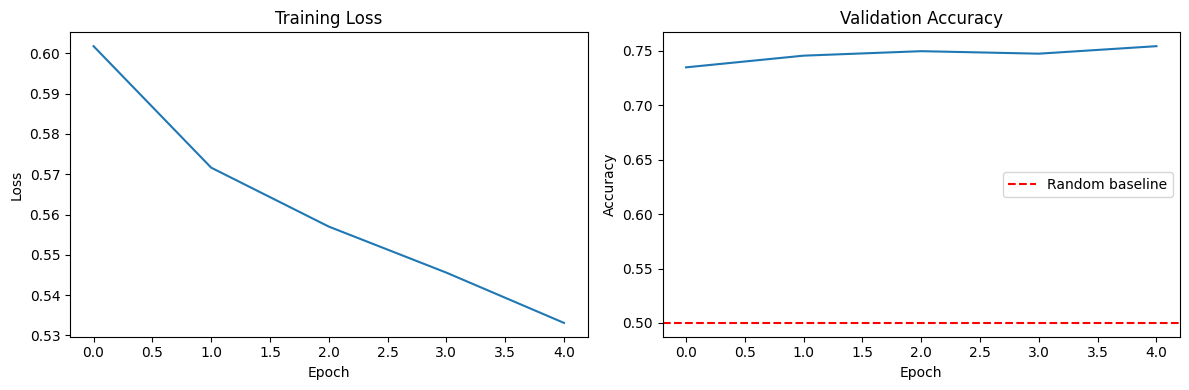

Final validation accuracy: 0.7544
Best validation accuracy: 0.7544


In [20]:
# CELL 11: Plot training progress
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='Random baseline')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final validation accuracy: {val_accuracies[-1]:.4f}")
print(f"Best validation accuracy: {max(val_accuracies):.4f}")